In [27]:
from utils import ASSETS_DIR
import torch
import torch.nn.functional as F
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
import numpy as np
import torch.nn as nn
from utils.models import load_all_skops
import torch.optim as optim
from sklearn.utils import resample
from utils.dataset import undersample_dataset
import models.quantum.quantum_machine_learning as qml

In [ ]:
cfg = qml.ExperimentConfig(
    n_qubits=6,
    input_dim=4,
    readout_name="ZXY",
    ansatz_function="ttn",
    encoding_function="rx",
    reps=1,
    encoding_range=(0, np.pi)
    
)

ansatz_kwargs = {
    "entanglement": "reverse_linear",

}


torch.manual_seed(cfg.seed)

In [29]:

dimension_padded, num_blocks, pad_size = qml.zero_padding(cfg.n_qubits, cfg.input_dim)

final_data = qml.build_quantum_circuit(real_qubits=cfg.n_qubits,
                                        encoding_depth=num_blocks,
                                          encoding_name=cfg.encoding_function,
                                            ansatz_name=cfg.ansatz_function,
                                              reps=cfg.reps,
                                                ansatz_kwargs=ansatz_kwargs
                                                  )
quantum_circuit = final_data['quantum_circuit']
weight_params = final_data['weight_params']
input_params = final_data['input_params']
quantum_circuit.draw('mpl')
print(final_data['weight_params'])

Costruzione del layer 0 con 6 qubits reali e 6 qubits totali
[ParameterVectorElement(θ_0[0]), ParameterVectorElement(θ_0[1]), ParameterVectorElement(θ_0[2]), ParameterVectorElement(θ_0[3]), ParameterVectorElement(θ_0[4]), ParameterVectorElement(θ_0[5]), ParameterVectorElement(θ_0[6]), ParameterVectorElement(θ_0[7]), ParameterVectorElement(θ_0[8]), ParameterVectorElement(θ_0[9]), ParameterVectorElement(θ_0[10]), ParameterVectorElement(θ_0[11]), ParameterVectorElement(θ_0[12]), ParameterVectorElement(θ_0[13]), ParameterVectorElement(θ_0[14])]


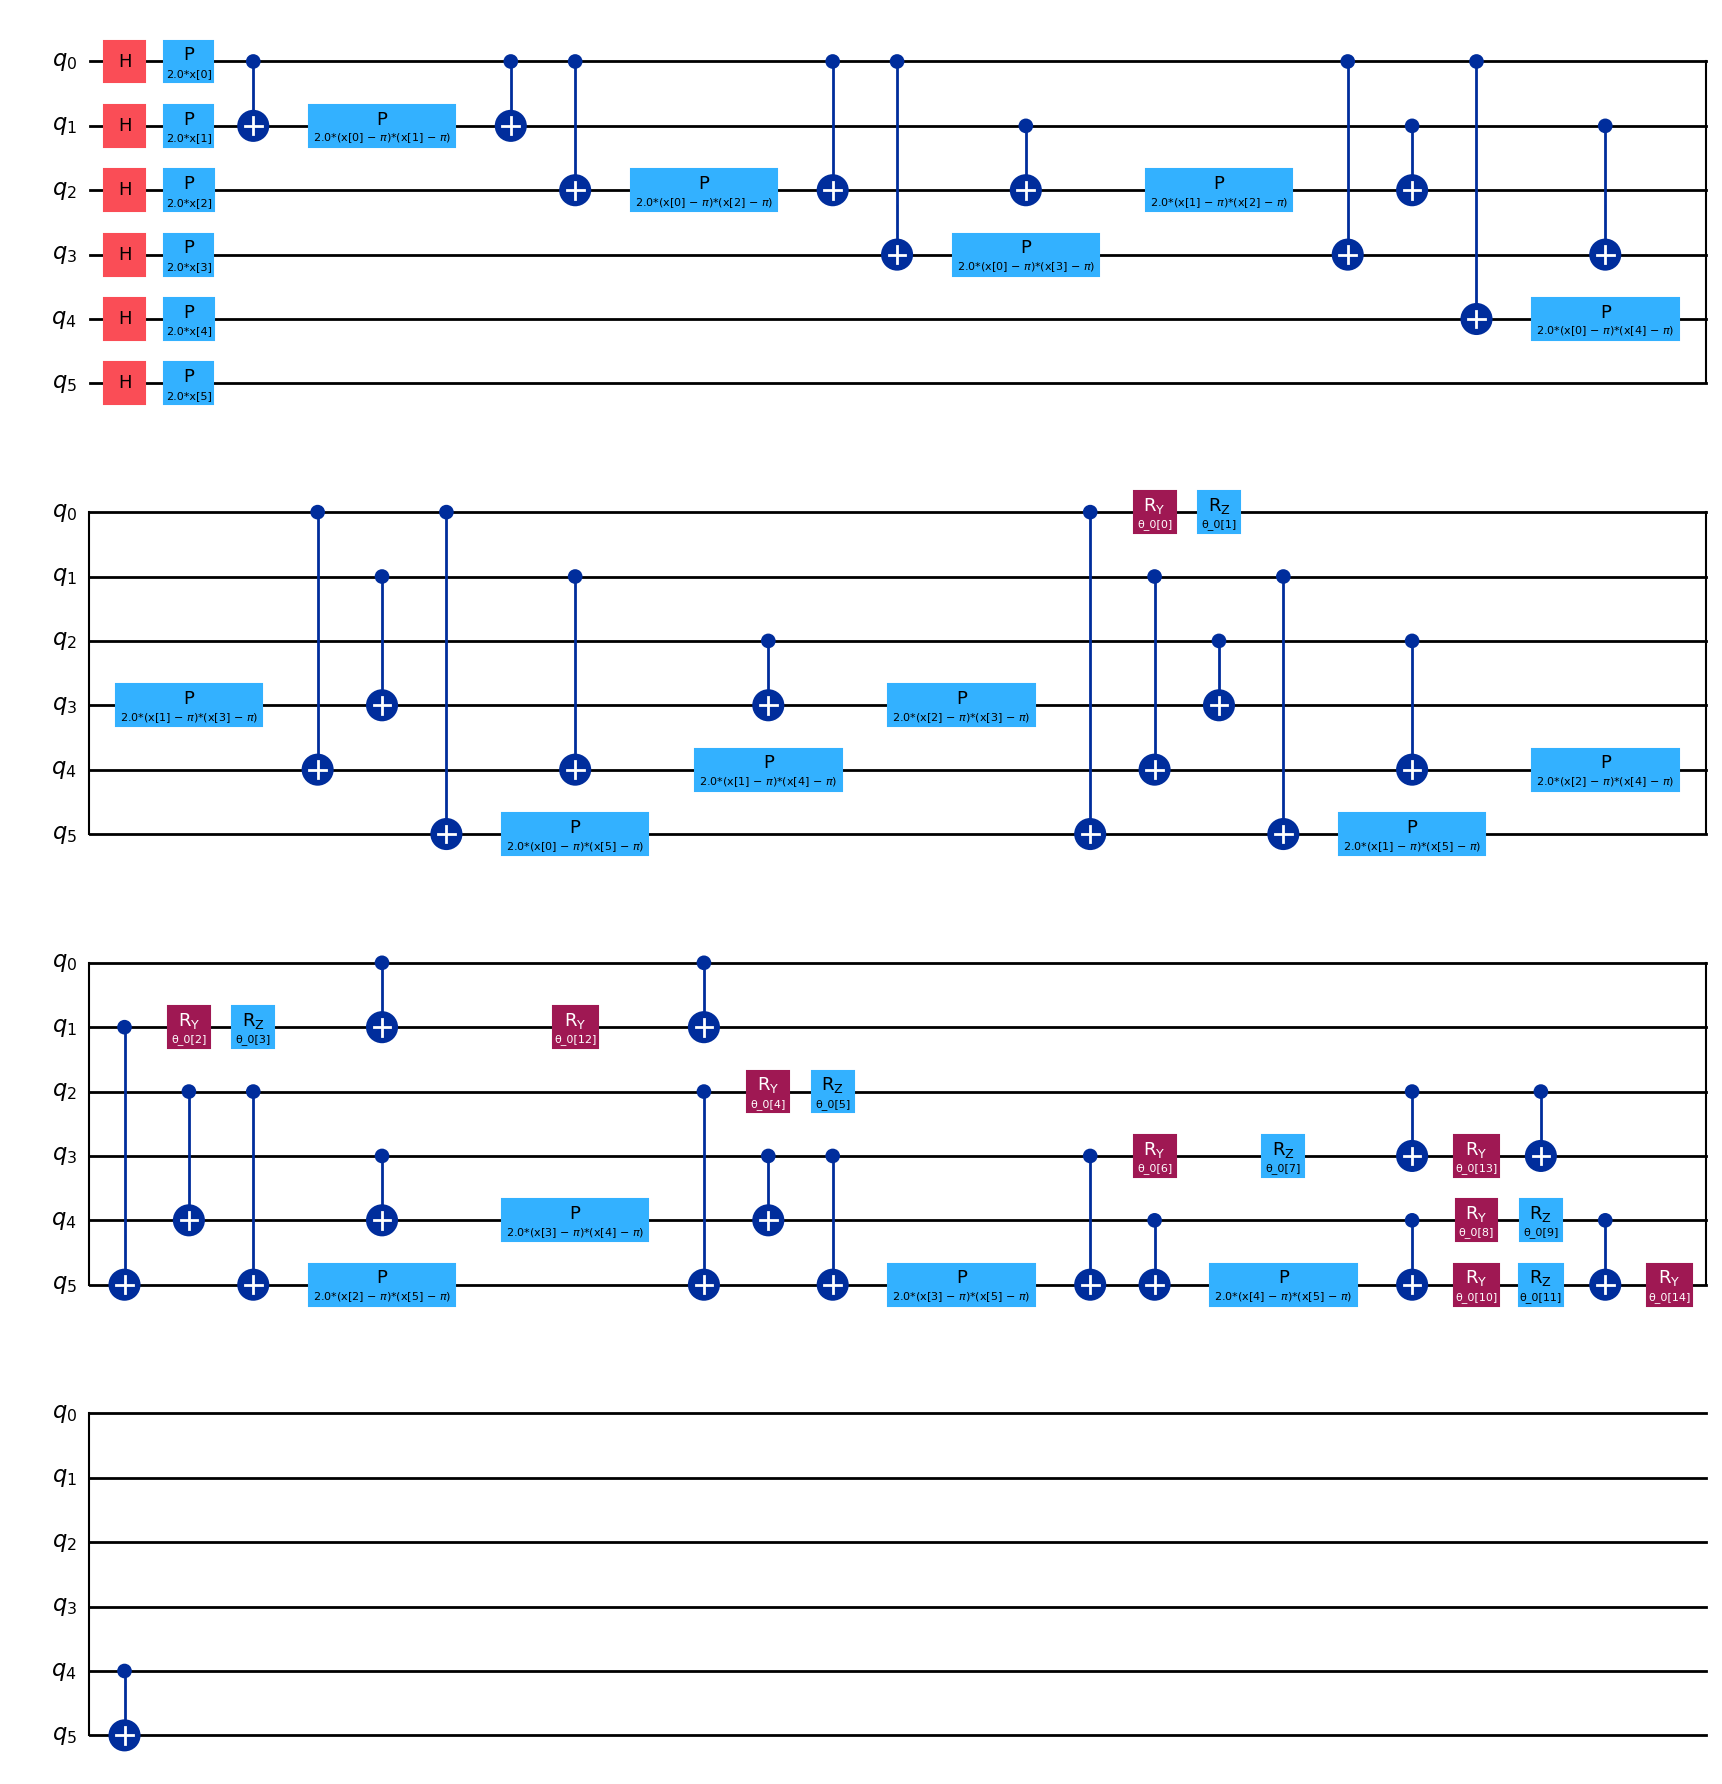

In [30]:
quantum_circuit.draw('mpl')

In [31]:

objs = load_all_skops(ASSETS_DIR / f"seeds_{cfg.seed}")
std_scaler = objs['scaler'] 
objs.pop('scaler')
pca = objs[f"pca_{cfg.input_dim}"]

'''TRAIN DATAFRAME'''
train_dataset = pd.read_csv(ASSETS_DIR / f"seeds_{cfg.seed}/train_{cfg.seed}.csv")
train_dataset = undersample_dataset(train_dataset, label_col='label', random_seed=cfg.seed)
#train_dataset = resample(train_dataset, replace=False, n_samples=10000, stratify=train_dataset["label"], random_state=cfg.seed)
X_train = train_dataset.drop(columns=["label"])



'''VALIDATION DATAFRAME'''
val_dataset = pd.read_csv(ASSETS_DIR / f"seeds_{cfg.seed}/val_{cfg.seed}.csv")
val_dataset = undersample_dataset(val_dataset, label_col='label', random_seed=cfg.seed)


#PCA su train
X_train = std_scaler.transform(X_train)
X_train = pca.transform(X_train)
Y_train = train_dataset["label"]

#PCA su val
X_val = val_dataset.drop(columns=["label"])
X_val = std_scaler.transform(X_val)
X_val = pca.transform(X_val)
Y_val = val_dataset["label"]

'''TEST DATAFRAME'''
test_dataset = pd.read_csv(ASSETS_DIR / f"seeds_{cfg.seed}/test_{cfg.seed}.csv")
X_test = test_dataset.drop(columns=["label"])
X_test = std_scaler.transform(X_test)
X_test = pca.transform(X_test)
Y_test = test_dataset["label"]



Caricamento di: scaler.skops...
scaler caricato con successo.
Caricamento di: pca_16.skops...
pca_16 caricato con successo.
Caricamento di: pca_4.skops...
pca_4 caricato con successo.
Caricamento di: pca_32.skops...
pca_32 caricato con successo.
Caricamento di: pca_8.skops...
pca_8 caricato con successo.
Distribuzione originale delle classi:
label
3    41112
0    29964
1     9278
2     7093
Name: count, dtype: int64

Classe minoritaria: 2 con 7093 elementi.
Classe 3: 41112 elementi -> campiono 7093
Classe 0: 29964 elementi -> campiono 7093
Classe 1: 9278 elementi -> campiono 7093
Classe 2: 7093 elementi -> campiono 7093

Dataset bilanciato - dimensione totale: 28372
Distribuzione finale:
label
1    7093
3    7093
0    7093
2    7093
Name: count, dtype: int64
Distribuzione originale delle classi:
label
3    5139
0    3746
1    1160
2     886
Name: count, dtype: int64

Classe minoritaria: 2 con 886 elementi.
Classe 3: 5139 elementi -> campiono 886
Classe 0: 3746 elementi -> campiono 886


In [32]:
del train_dataset
del val_dataset
del test_dataset

scaler = MinMaxScaler(feature_range=cfg.encoding_range)
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

tensor = torch.from_numpy(X_train).float()
tensor.size()
tensor_Y = torch.from_numpy(Y_train.values).long()

tensor_val = torch.from_numpy(X_val).float()
tensor_Y_val = torch.from_numpy(Y_val.values).long()

tensor_test = torch.from_numpy(X_test).float()
tensor_Y_test = torch.from_numpy(Y_test.values).long()

In [33]:


X_padded = F.pad(tensor, (0, pad_size), mode="constant", value=0.0)


dataset_train = torch.utils.data.TensorDataset(
    X_padded.float(),
    torch.from_numpy(Y_train.values).long()
)
print(f"Dataset train size: {dataset_train.__len__()} samples")
dataloader_train = torch.utils.data.DataLoader(dataset_train, batch_size=cfg.batch_size, shuffle=True, num_workers=12, pin_memory=True)

X_padded_val = F.pad(tensor_val, (0, pad_size), mode="constant", value=0.0)
dataset_val = torch.utils.data.TensorDataset(
    X_padded_val.float(),
    torch.from_numpy(Y_val.values).long()
)
print(f"Dataset val size: {dataset_val.__len__()} samples")
dataloader_val = torch.utils.data.DataLoader(dataset_val, batch_size=cfg.batch_size, shuffle=False, num_workers=12, pin_memory=True)


X_padded_test = F.pad(tensor_test, (0, pad_size), mode="constant", value=0.0)
dataset_test = torch.utils.data.TensorDataset(
    X_padded_test.float(),
    torch.from_numpy(Y_test.values).long()
)
print(f"Dataset test size: {dataset_test.__len__()} samples")
dataloader_test = torch.utils.data.DataLoader(dataset_test, batch_size=cfg.batch_size, shuffle=False, num_workers=12, pin_memory=True)


Dataset train size: 28372 samples
Dataset val size: 3544 samples
Dataset test size: 10931 samples


In [34]:

observables = qml.pauli_observable(cfg.n_qubits, cfg.readout_name)
print(observables)
 
quantum_model = qml.VQC(cfg.n_qubits, 
                        quantum_circuit=quantum_circuit,
                        obs=observables,
                        weight_params=weight_params,
                        input_params=input_params,
                        target_classes=cfg.num_classes,
                        gradient_mode='estimator_pauli_batched_spsa'
                        )
quantum_model.to("cuda")

[SparsePauliOp(['IIIIIZ'],
              coeffs=[1.+0.j]), SparsePauliOp(['IIIIZI'],
              coeffs=[1.+0.j]), SparsePauliOp(['IIIZII'],
              coeffs=[1.+0.j]), SparsePauliOp(['IIZIII'],
              coeffs=[1.+0.j]), SparsePauliOp(['IZIIII'],
              coeffs=[1.+0.j]), SparsePauliOp(['ZIIIII'],
              coeffs=[1.+0.j]), SparsePauliOp(['IIIIIX'],
              coeffs=[1.+0.j]), SparsePauliOp(['IIIIXI'],
              coeffs=[1.+0.j]), SparsePauliOp(['IIIXII'],
              coeffs=[1.+0.j]), SparsePauliOp(['IIXIII'],
              coeffs=[1.+0.j]), SparsePauliOp(['IXIIII'],
              coeffs=[1.+0.j]), SparsePauliOp(['XIIIII'],
              coeffs=[1.+0.j]), SparsePauliOp(['IIIIIY'],
              coeffs=[1.+0.j]), SparsePauliOp(['IIIIYI'],
              coeffs=[1.+0.j]), SparsePauliOp(['IIIYII'],
              coeffs=[1.+0.j]), SparsePauliOp(['IIYIII'],
              coeffs=[1.+0.j]), SparsePauliOp(['IYIIII'],
              coeffs=[1.+0.j]), SparsePauliOp

VQC(
  (head_classical_linear_layer): Linear(in_features=18, out_features=4, bias=True)
)

In [35]:
epochs = cfg.epochs
optimizer = optim.Adam(quantum_model.parameters(), lr=cfg.learning_rate)
criterion = nn.CrossEntropyLoss()


In [36]:
import time
from sklearn.metrics import f1_score, classification_report, roc_auc_score
from torchmetrics.classification import MulticlassCalibrationError
ece_metric = MulticlassCalibrationError(num_classes=4, n_bins=15, norm='l1').to("cuda")

report = {"val_loss": [], "val_f1": [], "epoch_time": [], "train_loss": [], "epoch": [], "val_classification_reports": [], "val_ece": [], "val_auc": []}

best_val_loss = float("inf")
best_epoch = 0
best_model_state = None
patience = getattr(cfg, "early_stopping_patience", 5)
epochs_no_improve = 0

for epoch in range(epochs):
    
    running_loss = 0.0
    start_time = time.time()
    one_time = True

    quantum_model.train()
    # Il dataloader_train fornisce iterativamente i batch (es. da 32)
    for batch_X, batch_y in dataloader_train:
        
        if one_time:
            print(f"Batch size: {batch_X[0].shape}")
            print(f"Use batched estimator SPSA: {quantum_model._use_batched_estimator_spsa}")
            one_time = False
        

        batch_X = batch_X.to("cuda", non_blocking=True)
        batch_y = batch_y.to("cuda", non_blocking=True)
        
        # A. Azzeriamo i gradienti
        optimizer.zero_grad()
        
        # B. FORWARD PASS
        # Qui la QNN crea in automatico il PUB per l'intero batch e lo esegue
        logits = quantum_model(batch_X)
       

        '''print(f"Shape di logits: {logits.shape}")
        print(f"Shape di batch_y: {batch_y.shape}")
        print(f"Tipo di batch_y: {batch_y.dtype}")'''
        
        # C. Calcolo della Loss
        loss = criterion(logits, batch_y)
        loss.backward()
        # E. Aggiornamento dei pesi
        optimizer.step()
        
        running_loss += loss.item()

        print("#", end="")
    print()  # Per andare a capo dopo la barra di avanzamento

    quantum_model.eval()
    ece_metric.reset()
    with torch.no_grad():
        val_loss = 0.0
        y_true = []
        y_pred = []
        y_probs = []
        
        for batch_X, batch_y in dataloader_val:
            batch_X = batch_X.to("cuda", non_blocking=True)
            batch_y = batch_y.to("cuda", non_blocking=True)
            logits = quantum_model(batch_X)

            # Trasformazione logit -> probabilità per AUROC ed ECE [1]
            probs = torch.softmax(logits, dim=1)
            ece_metric.update(probs, batch_y)


            loss = criterion(logits, batch_y)
            val_loss += loss.item()
            preds = logits.argmax(dim=1).cpu().numpy()
            y_pred.extend(preds.tolist())
            y_true.extend(batch_y.cpu().numpy().tolist())
            y_probs.extend(probs.cpu().numpy().tolist())
        

        val_loss = val_loss / len(dataloader_val)
        auroc = roc_auc_score(y_true, y_probs, multi_class='ovr', average='macro')
        ece_val = ece_metric.compute().item()
        f1 = f1_score(y_true, y_pred, average='macro')
        print(f"Classification Report E{epoch+1}:\n{classification_report(y_true, y_pred)}")
        report["val_classification_reports"].append(classification_report(y_true, y_pred, output_dict=True))
        report["val_ece"].append(ece_val)
        report["val_auc"].append(auroc)
        #print(f"Val loss: {val_loss:.4f}")
        #print(f"Val F1: {f1:.4f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_epoch = epoch + 1
        best_model_state = quantum_model.state_dict()
        epochs_no_improve = 0
        print(f"Nuovo miglior validation loss: {best_val_loss:.4f} all'epoca {best_epoch}")
    else:
        epochs_no_improve += 1
        print(f"Non miglioramento: {epochs_no_improve}/{patience}")

    if epochs_no_improve >= patience:
        print(f"Early stopping: stop dopo epoca {epoch+1}. Miglior epoca: {best_epoch}.")
        break

    step_time = time.time() - start_time
        
    print(f"Tempo per epoca {epoch+1}: {step_time:.2f} secondi")
    
    loss_media = running_loss / len(dataloader_train)
    report["val_loss"].append(val_loss)
    report["val_f1"].append(f1)
    report["epoch_time"].append(step_time)
    report["train_loss"].append(loss_media)
    report["epoch"].append(epoch+1)

    print(f"Epoca {epoch+1}/{epochs} - Loss: {loss_media:.4f}")

if best_model_state is not None:
    quantum_model.load_state_dict(best_model_state)

report["best_epoch"] = best_epoch
report["best_val_loss"] = best_val_loss
report["early_stopping_patience"] = patience

Batch size: torch.Size([6])
Use batched estimator SPSA: True
##############################################################################################################################################################################################################################
Classification Report E1:
              precision    recall  f1-score   support

           0       0.26      0.19      0.22       886
           1       0.31      0.07      0.11       886
           2       0.26      0.52      0.35       886
           3       0.27      0.29      0.28       886

    accuracy                           0.27      3544
   macro avg       0.27      0.27      0.24      3544
weighted avg       0.27      0.27      0.24      3544

Nuovo miglior validation loss: 1.3834 all'epoca 1
Tempo per epoca 1: 29.15 secondi
Epoca 1/50 - Loss: 1.3871
Batch size: torch.Size([6])
Use batched estimator SPSA: True
#####################################################################################

In [37]:

classification_report_dict = classification_report(y_true, y_pred, output_dict=True)
df_report = pd.DataFrame(classification_report_dict).transpose()
print(df_report)

              precision    recall  f1-score      support
0              0.352467  0.395034  0.372539   886.000000
1              0.328253  0.316027  0.322024   886.000000
2              0.345259  0.217833  0.267128   886.000000
3              0.334504  0.430023  0.376296   886.000000
accuracy       0.339729  0.339729  0.339729     0.339729
macro avg      0.340121  0.339729  0.334497  3544.000000
weighted avg   0.340121  0.339729  0.334497  3544.000000


In [38]:
quantum_model.eval()
ece_metric.reset()
y_true = []
y_pred = []
y_probs = []

with torch.no_grad():
    for batch_X, batch_y in dataloader_test:
        batch_X = batch_X.to("cuda", non_blocking=True)
        batch_y = batch_y.to("cuda", non_blocking=True)
        
        

        logits = quantum_model(batch_X)
        probs = torch.softmax(logits, dim=1)
        ece_metric.update(probs, batch_y)
        y_probs.extend(probs.cpu().numpy().tolist())
        preds = logits.argmax(dim=1).cpu().numpy()
        y_pred.extend(preds.tolist())
        y_true.extend(batch_y.cpu().numpy().tolist())


test_auroc = roc_auc_score(y_true, y_probs, multi_class='ovr', average='macro')
test_ece = ece_metric.compute().item()
report["test_classification_report"] = classification_report(y_true, y_pred, output_dict=True)
report["test_auc"] = test_auroc
report["test_ece"] = test_ece
print(f"Classification Report Test:\n{classification_report(y_true, y_pred)}")
print(f"Test AUROC: {test_auroc:.4f}")
print(f"Test ECE: {test_ece:.4f}")

Classification Report Test:
              precision    recall  f1-score   support

           0       0.46      0.40      0.43      3745
           1       0.14      0.31      0.19      1160
           2       0.11      0.21      0.14       887
           3       0.58      0.40      0.47      5139

    accuracy                           0.37     10931
   macro avg       0.32      0.33      0.31     10931
weighted avg       0.46      0.37      0.40     10931

Test AUROC: 0.5992
Test ECE: 0.0374


In [39]:
run_dir = qml.salva_esperimento_locale(cfg, ansatz_kwargs, report, y_true_test=y_true, y_pred_test=y_pred)


✅ Esperimento salvato localmente con successo!
📂 Cartella: /home/kirjia/ProgettoQuantumBioetria/src/assets/experiments/VQC_q6_dim4_seed_11_ansatzttn_key_ae67cf1c
